**A.  DATASET EXPLORATION :**

1. IMPORT DATASET and RENAME COLUMNS :

In [ ]:
import pandas as pd



original_df = pd.read_csv("/content/SMSSpamCollection", sep="\t",header=None,names=["Label(spam/ham)", "Message(text)"])
print(original_df.head())


  Label(spam/ham)                                      Message(text)
0             ham  Go until jurong point, crazy.. Available only ...
1             ham                      Ok lar... Joking wif u oni...
2            spam  Free entry in 2 a wkly comp to win FA Cup fina...
3             ham  U dun say so early hor... U c already then say...
4             ham  Nah I don't think he goes to usf, he lives aro...


2. NUMBER OF SPAM vs HAM messages :

In [ ]:
print(original_df['Label(spam/ham)'].value_counts())

Label(spam/ham)
ham     4825
spam     747
Name: count, dtype: int64


3. AVERAGE MESSAGE LENGTH :

In [ ]:
average_length_of_messages = original_df['Message(text)'].apply(len).mean()
print(f"Average message length : {average_length_of_messages:.2f} characters")

Average message length : 80.49 characters


4. PLOT CLASS DISTRIBUTION :

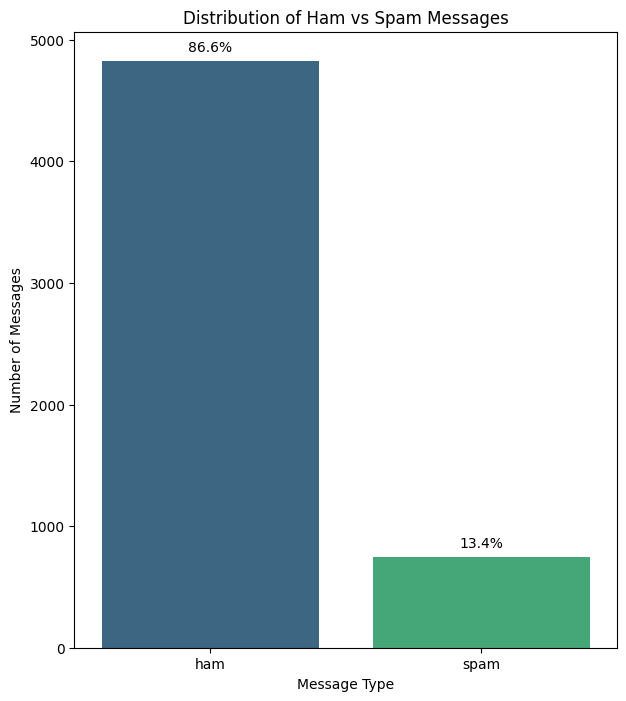

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Value counts for the 'Label(spam/ham)' column
label_counts = original_df['Label(spam/ham)'].value_counts()

# Proportions of the classes
total_messages = label_counts.sum()
probabilities = (label_counts / total_messages) * 100

# Bar plot
plt.figure(figsize=(7, 8))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis', hue=label_counts.index, legend=False)
plt.title('Distribution of Ham vs Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

for p in ax.patches:
    ax.annotate(f'{p.get_height()/total_messages:.1%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

4. I MADE A NEW DATAFRAME AND HAVE DONE STEP 2 OF THE ASSIGNMENT USING "step2_df" INSTEAD OF "original_df"

In [ ]:
step2_df = original_df.copy()

**QUESTIONS**

1.   The plot distribution clearly indicates the dataset is not balanced , there are far more ham messages than spam
2.   Based on my analysis of the SMS Spam Collection dataset, I found that spam messages are generally longer than ham messages. From my dataset, the overall average message length was about 80 characters, but when I looked closer, spam messages tend to be longer because they include promotional offers, instructions, terms and conditions, and phone numbers. Ham messages, on the other hand, are usually short and conversational, often just a few words or a simple sentence between friends. For example, a typical ham message might be something like "Ok lar... Joking wif u oni..." which is quite short, while a spam message often contains multiple sentences with details about prizes, how to claim them, and disclaimers. This difference in length is one of the features that helps distinguish spam from ham.



**B. TEXT PREPROCESSING**

1. CONVERTING TEXT INTO LOWER CASE:

In [ ]:
step2_df['Message(text)_lower'] = step2_df['Message(text)'].apply(lambda x: x.lower())
display(step2_df.head())

,Label(spam/ham),Message(text),Message(text)_lower
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


2. REMOVING PUNCTUATIONS

In [ ]:
import string

# Function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# NEW COLUMN
step2_df['Message(text)_lower_no_punct'] = step2_df['Message(text)_lower'].apply(remove_punctuation)

display(step2_df.head())

,Label(spam/ham),Message(text),Message(text)_lower,Message(text)_lower_no_punct
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


3. REMOVING STOPWORDS

In [ ]:
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords if not already there
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Function to remove stopwords
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Apply the function to the 'Message(text)_lower_no_punct' column
step2_df['Message(text)_lower_no_punct_no_stopwords'] = step2_df['Message(text)_lower_no_punct'].apply(remove_stopwords)

display(step2_df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Label(spam/ham),Message(text),Message(text)_lower,Message(text)_lower_no_punct,Message(text)_lower_no_punct_no_stopwords
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...",go until jurong point crazy available only in ...,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,ok lar joking wif u oni,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,free entry in 2 a wkly comp to win fa cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,u dun say so early hor u c already then say,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,nah dont think goes usf lives around though


5. TOKENIZATION

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Download the 'punkt' tokenizer and 'punkt_tab' if not already there
try:
    word_tokenize('test')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Function to tokenize text
def tokenize_text(text):
    return word_tokenize(text)

# Apply the function to the 'Message(text)_lower_no_punct_no_stopwords' column
step2_df['Message(text)_l_p_s_tokens'] = step2_df['Message(text)_lower_no_punct_no_stopwords'].apply(tokenize_text)

display(step2_df.head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Label(spam/ham),Message(text),Message(text)_lower,Message(text)_lower_no_punct,Message(text)_lower_no_punct_no_stopwords,Message(text)_l_p_s_tokens
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...",go until jurong point crazy available only in ...,go jurong point crazy available bugis n great ...,"[go, jurong, point, crazy, available, bugis, n..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,ok lar joking wif u oni,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,free entry in 2 a wkly comp to win fa cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,"[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,u dun say so early hor u c already then say,u dun say early hor u c already say,"[u, dun, say, early, hor, u, c, already, say]"
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,nah dont think goes usf lives around though,"[nah, dont, think, goes, usf, lives, around, t..."


6. STEMMING

In [ ]:
import nltk
from nltk.stem import PorterStemmer


# Initialize Porter Stemmer
porter_stemmer = PorterStemmer()

# Function to apply stemming to a list of tokens
def stem_tokens(tokens):
    return [porter_stemmer.stem(word) for word in tokens]

# Apply the stemming function to the tokenized column
step2_df['Message(text)_l_p_s_tokens_stemmed'] = step2_df['Message(text)_l_p_s_tokens'].apply(stem_tokens)

display(step2_df.head())


,Label(spam/ham),Message(text),Message(text)_lower,Message(text)_lower_no_punct,Message(text)_lower_no_punct_no_stopwords,Message(text)_l_p_s_tokens,Message(text)_l_p_s_tokens_stemmed
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...",go until jurong point crazy available only in ...,go jurong point crazy available bugis n great ...,"[go, jurong, point, crazy, available, bugis, n...","[go, jurong, point, crazi, avail, bugi, n, gre..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,ok lar joking wif u oni,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]","[ok, lar, joke, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,free entry in 2 a wkly comp to win fa cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,"[free, entry, 2, wkly, comp, win, fa, cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,u dun say so early hor u c already then say,u dun say early hor u c already say,"[u, dun, say, early, hor, u, c, already, say]","[u, dun, say, earli, hor, u, c, alreadi, say]"
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,nah dont think goes usf lives around though,"[nah, dont, think, goes, usf, lives, around, t...","[nah, dont, think, goe, usf, live, around, tho..."


**TASK :COMPARING STEMMED AND ORIGINAL MESSAGES**

In [ ]:
display(step2_df[['Message(text)', 'Message(text)_l_p_s_tokens_stemmed']].head())

,Message(text),Message(text)_l_p_s_tokens_stemmed
0,"Go until jurong point, crazy.. Available only ...","[go, jurong, point, crazi, avail, bugi, n, gre..."
1,Ok lar... Joking wif u oni...,"[ok, lar, joke, wif, u, oni]"
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,U dun say so early hor... U c already then say...,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,"Nah I don't think he goes to usf, he lives aro...","[nah, dont, think, goe, usf, live, around, tho..."


**C. FEATURE ENGINEERING**

1. STEMMED TOKENS TO STRING :

In [ ]:
step2_df['Message(text)_stemmed_string'] = step2_df['Message(text)_l_p_s_tokens_stemmed'].apply(lambda x: ' '.join(x))
display(step2_df[['Message(text)', 'Message(text)_stemmed_string']].head())

,Message(text),Message(text)_stemmed_string
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


2. NOW THAT WE HAVE THE STEMMED TOKENS JOINED BACK INTO STRINGS, WE CAN APPLY TF-IDF TO CONVERT THEM INTO NUMERICAL FEATURES, APPLYING TF-IDF :

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the stemmed messages
X = vectorizer.fit_transform(step2_df['Message(text)_stemmed_string'])

# Shape of the resulting feature matrix
print(f"Shape of feature matrix (X): {X.shape}")

# First 10 feature names (words)
print("First 10 feature names:")
print(vectorizer.get_feature_names_out()[:10])

Shape of feature matrix (X): (5572, 8098)
First 10 feature names:
['008704050406' '0089mi' '0121' '01223585236' '01223585334' '0125698789'
 '02' '020603' '0207' '02070836089']


In [ ]:
feature_names = vectorizer.get_feature_names_out()

# For demonstration, let's take the first 5 rows and convert to dense
sample_X_dense = X[:5].toarray()
sample_df = pd.DataFrame(sample_X_dense, columns=feature_names)

display(sample_df.head())

,008704050406,0089mi,0121,01223585236,01223585334,0125698789,02,020603,0207,02070836089,...,zero,zhong,zindgi,zoe,zogtoriu,zoom,zouk,zyada,üll,〨ud
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


3. SPLITTING DATA INTO TRAINING AND TESTING DATASETS


In [ ]:
from sklearn.model_selection import train_test_split

# Definition of features (X) and labels (y)
X_data = step2_df['Message(text)_stemmed_string']
y = step2_df['Label(spam/ham)']

# Split the data into training and testing sets
# Using stratify=y to ensure that the proportion of spam/ham messages is the same in both train and test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_data, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Shape of X_train_raw: {X_train_raw.shape}")
print(f"Shape of X_test_raw: {X_test_raw.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of labels in training set:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of labels in testing set:")
print(y_test.value_counts(normalize=True))

Shape of X_train_raw: (4457,)
Shape of X_test_raw: (1115,)
Shape of y_train: (4457,)
Shape of y_test: (1115,)

Distribution of labels in training set:
Label(spam/ham)
ham     0.865829
spam    0.134171
Name: proportion, dtype: float64

Distribution of labels in testing set:
Label(spam/ham)
ham     0.866368
spam    0.133632
Name: proportion, dtype: float64


### TASK Fitting TF-IDF Vectorizer on Training Data and Transforming Data

Now we will fit the `TfidfVectorizer` specifically on the `X_train_raw` (training messages) to learn the vocabulary and inverse document frequencies from the training data only. Then, we will transform both `X_train_raw` and `X_test_raw` using this fitted vectorizer.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Re-initialize TfidfVectorizer again (or reuse the existing one if it's not already fitted)
vectorizer_train = TfidfVectorizer()

# Fitting the vectorizer on the training data and transform it
X_train = vectorizer_train.fit_transform(X_train_raw)

# Transforming test data using the SAME fitted vectorizer
X_test = vectorizer_train.transform(X_test_raw)

print(f"Shape of TF-IDF transformed X_train: {X_train.shape}")
print(f"Shape of TF-IDF transformed X_test: {X_test.shape}")

# Display the first 10 feature names learned from the training data
print("\nFirst 10 feature names from training data:")
print(vectorizer_train.get_feature_names_out()[:10])

Shape of TF-IDF transformed X_train: (4457, 7118)
Shape of TF-IDF transformed X_test: (1115, 7118)

First 10 feature names from training data:
['008704050406' '0089mi' '0121' '01223585236' '01223585334' '02' '020603'
 '0207' '02070836089' '02072069400']


**QUESTION :DIMENSION OF FEATURE SPACE (TEST DATA): 4457 training samples and 7118 features after preprocessing .**

**D. LOGISTIC REGRESSION MODEL**

1. TRAIN LOGISTIC REGRESSION MODEL (SPLIT ALREADY DONE DURING VECTORIZATION) :

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

2. DISPLAYING LEARNED COEFFICIENTS OF THE LOGISTIC REGRESSION MODEL

In [27]:
feature_names = vectorizer_train.get_feature_names_out()
coefficients = log_reg_model.coef_[0]
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False)

print("All features with their coefficients (sorted by coefficient value):")
display(coef_df_sorted)

All features with their coefficients (sorted by coefficient value):


,Feature,Coefficient
6452,txt,4.940246
1792,claim,3.699760
5938,stop,3.410448
5526,servic,3.319111
5256,repli,3.241046
...,...,...
1854,come,-1.453796
4603,ok,-1.775668
3383,ill,-1.848377
3978,ltgt,-2.028262


**QUESTIONS** :
1.   Positive coefficient of a vector indicates that the word is most probably a spam indicator .
2.   The words txt , claim , stop, servic, repli are top indicators of spam .



**E. EVALUATION MATRIX & CONFUSION MATRIX :**

Accuracy: 0.9614
F1 Score: 0.8314
Precision: 1.0000
Recall: 0.7114

Confusion Matrix:
[[966   0]
 [ 43 106]]
   


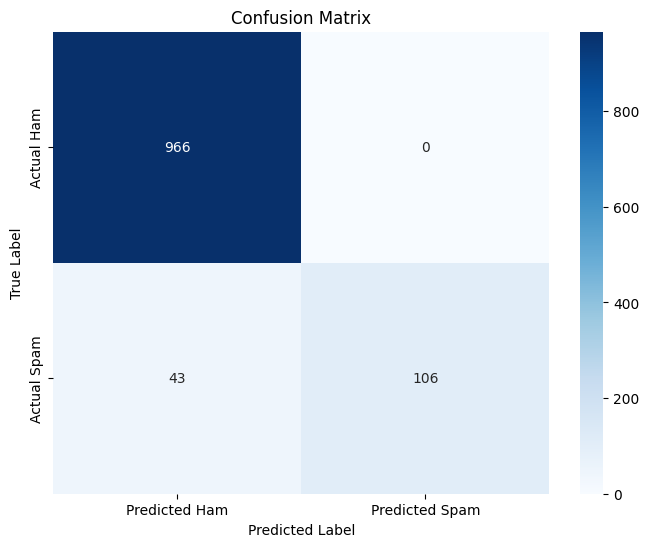

In [31]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label='spam') # Specify positive label for binary classification
precision = precision_score(y_test, y_pred, pos_label='spam')
recall = recall_score(y_test, y_pred, pos_label='spam')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=['ham', 'spam']) # Specify labels for clear order

print("\nConfusion Matrix:")
print(conf_matrix)
print("   ")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**QUESTIONS :**

1.   Accuracy is not sufficient for spam detection because the dataset is imbalanced, with ham messages making up about 87% of the data. A model could simply predict all messages as "ham" and still achieve 87% accuracy while failing to detect any spam
2.   For spam detection, recall is the most important metric because it measures how many actual spam messages the model successfully catches. Missing a spam message (false negative) means spam reaches the user's inbox, which defeats the purpose of spam filtering. While precision matters too (avoiding false positives where ham is marked as spam), recall ensures the primary goal of spam detection is achieved.



CLASSIFICATION REPORT

In [32]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))


Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.71      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115



**E. INTERPRETATION AND INSIGHT**

In [33]:
print("Top 10 features with the highest positive coefficients (most spam-indicative):")
display(coef_df_sorted.head(10))

Top 10 features with the highest positive coefficients (most spam-indicative):


,Feature,Coefficient
6452,txt,4.940246
1792,claim,3.699760
5938,stop,3.410448
5526,servic,3.319111
5256,repli,3.241046
2777,free,3.226804
4234,mobil,3.222441
6175,text,2.917565
1591,call,2.858411
5023,prize,2.827509


In [34]:
print("\nTop 10 features with the highest negative coefficients (most ham-indicative):")
display(coef_df_sorted.tail(10))


Top 10 features with the highest negative coefficients (most ham-indicative):


,Feature,Coefficient
3245,home,-1.304137
5799,sorri,-1.330537
3791,later,-1.353173
2986,got,-1.367188
2041,da,-1.374673
1854,come,-1.453796
4603,ok,-1.775668
3383,ill,-1.848377
3978,ltgt,-2.028262
3386,im,-2.157521


**COMMON CHARACTERISTICS OF SPAM MESSAGES:**

---



Based on analysis of the SMS Spam Collection dataset, spam messages exhibit several common characteristics:

Length and Structure: Spam messages are typically longer than ham messages, often containing multiple sentences with a clear structure including an offer, instructions to claim, and terms and conditions. They follow a formulaic pattern rather than natural conversation.

Content and Purpose: Spam messages are promotional or scam-related, designed to trick users into calling premium numbers, texting short codes, or claiming fake prizes. They rarely contain personal context or conversational elements.

Frequent Keywords: Spam messages commonly contain words like "free", "win", "prize", "text", "call", "claim", "urgent", "stop", "mobile", and "reply". These words serve as strong indicators of promotional content.

Contact Information: Spam messages almost always include phone numbers, short codes, URLs, or prize amounts. This contrasts with ham messages where contact details appear only rarely in personal contexts.

Urgency and Tone: Spam messages create artificial urgency using words like "URGENT", "2nd attempt", or "claim now" to pressure recipients into immediate action. The tone is overly positive and exciting, using phrases like "You've WON!" or "Congratulations!"

Formatting: Spam messages frequently use ALL CAPS, excessive punctuation like "!!!", or random capitalization to grab attention. They often include symbols like "£" or "$" to emphasize monetary rewards.

Language Patterns: Spam messages use complete sentences and formal instructions rather than the fragmented, slang-heavy language common in personal texts. They lack personal pronouns and conversational markers like "lol" or "haha".

These characteristics collectively make spam messages distinct from legitimate personal communication, enabling classification models to identify them effectively.

**LIMITATIONS OF LOGISTIC REGRESSION :**

---




Based on my experience building a spam detection model, logistic regression has several limitations:

Linear Decision Boundary: Logistic regression assumes a linear relationship between features and the outcome. For text classification like spam detection, relationships between words and spam labels are often non-linear and complex, which logistic regression may not capture effectively.

Feature Interactions: The model cannot automatically learn interactions between features. For example, the combination of "free" and "text" might be more indicative of spam than either word alone, but logistic regression treats them independently unless manually specified.

Multicollinearity Sensitivity: It performs poorly when features are highly correlated, which is common in text data where words like "win" and "winner" appear together frequently, leading to unstable coefficient estimates.

High-Dimensional Data: When features exceed samples, which happens with TF-IDF vectors having thousands of features, logistic regression can overfit unless strong regularization is applied.

Outlier Sensitivity: The model is sensitive to outliers, where unusual or rare words can disproportionately influence coefficients.

No Automatic Feature Selection: All features contribute to predictions, including irrelevant or noisy words that may reduce performance.

Despite these limitations, logistic regression remains effective for spam detection due to its simplicity, speed, and strong baseline performance when combined with proper regularization.